### Step 1 — Mount Drive and define paths

In [1]:
# Step 1: Mount Google Drive and define paths

from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "phase3_tuning_round1"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_MANIFEST = SPLIT_DIR / "train_pairs_3d_train_phase3_2000.json"
VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

print("BASE_DIR exists:", BASE_DIR.exists())
print("TRAIN_MANIFEST exists:", TRAIN_MANIFEST.exists())
print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("OUT_DIR exists:", OUT_DIR.exists())
print("CKPT_DIR exists:", CKPT_DIR.exists())

Mounted at /content/drive
BASE_DIR exists: True
TRAIN_MANIFEST exists: True
VAL_MANIFEST exists: True
OUT_DIR exists: True
CKPT_DIR exists: True


### Step 2 — Imports and speed settings

In [2]:
# Step 2: Imports and speed settings

import json
import random
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

torch.backends.cudnn.benchmark = True

### Step 3 — Reuse verified definitions

In [3]:
# Step 3: Paste the following verified definitions here from working notebook:
# - CubePair3DDataset
# - ConditionalUNetFlow3D
# - euler_sample_flow_3d
# - compute_flow_matching_loss
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)   # (1,D,H,W)
        x1 = torch.from_numpy(x1).unsqueeze(0)   # (1,D,H,W)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        # xt, x0: (B,1,D,H,W)
        # t:      (B,1,1,1,1)
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])  # (B,1,D,H,W)
        inp = torch.cat([xt, x0, t_map], dim=1)  # (B,3,D,H,W)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)  # predicted velocity


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    """
    x0: (B,1,D,H,W)
    """
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z


def sample_t_like(x):
    return torch.rand((x.shape[0], 1, 1, 1, 1), device=x.device)


def compute_flow_matching_loss(model, x0, x1):
    t = sample_t_like(x0)
    z_t = (1.0 - t) * x0 + t * x1
    v_target = x1 - x0
    v_pred = model(z_t, x0, t)
    return F.mse_loss(v_pred, v_target)

### Step 4 — Set seeds and device

In [4]:
# Step 4: Set random seeds and device

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA H100 80GB HBM3


### Step 5 — Build datasets and loaders

In [5]:
# Step 5: Build datasets and loaders

DOSE_SCALE = 1000.0
NUM_WORKERS = 2

train_dataset_3d = CubePair3DDataset(TRAIN_MANIFEST, dose_scale=DOSE_SCALE)
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

print("Train dataset length:", len(train_dataset_3d))
print("Val dataset length:", len(val_dataset_3d))

Train dataset length: 2000
Val dataset length: 500


### Step 6 — Define Round-1 experiment configs

In [6]:
# Step 6: Define Round-1 experiment configs

ROUND1_CONFIGS = [
    {"run_name": "lr1e4_base24_bs2", "lr": 1e-4, "base_ch": 24, "batch_size": 2, "epochs": 30},
    {"run_name": "lr3e4_base24_bs2", "lr": 3e-4, "base_ch": 24, "batch_size": 2, "epochs": 30},
    {"run_name": "lr5e4_base24_bs2", "lr": 5e-4, "base_ch": 24, "batch_size": 2, "epochs": 30},
    {"run_name": "lr3e4_base32_bs2", "lr": 3e-4, "base_ch": 32, "batch_size": 2, "epochs": 30},
]

pd.DataFrame(ROUND1_CONFIGS)

,run_name,lr,base_ch,batch_size,epochs
0,lr1e4_base24_bs2,0.0001,24,2,30
1,lr3e4_base24_bs2,0.0003,24,2,30
2,lr5e4_base24_bs2,0.0005,24,2,30
3,lr3e4_base32_bs2,0.0003,32,2,30


### Step 7 — Helper functions: loaders, training, evaluation, checkpointing

In [7]:
# Step 7: Helper functions

def make_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset_3d,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0)
    )

    val_loader = DataLoader(
        val_dataset_3d,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0)
    )
    return train_loader, val_loader


def train_one_epoch_flow(model, loader, optimizer, device, scaler):
    model.train()

    total_loss = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = compute_flow_matching_loss(model, x0, x1)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate_flow_matching_loss(model, loader, device):
    model.eval()

    total_loss = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            loss = compute_flow_matching_loss(model, x0, x1)

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate_flow_prediction_metrics(model, loader, device, n_steps=30):
    model.eval()

    total_mse = 0.0
    total_mae = 0.0
    n_batches = 0

    for x0, x1 in loader:
        x0 = x0.to(device, non_blocking=True)
        x1 = x1.to(device, non_blocking=True)

        pred = euler_sample_flow_3d(model, x0, n_steps=n_steps)

        total_mse += F.mse_loss(pred, x1).item()
        total_mae += F.l1_loss(pred, x1).item()
        n_batches += 1

    return {
        "mse": total_mse / max(n_batches, 1),
        "mae": total_mae / max(n_batches, 1),
    }


def save_checkpoint(path, model, optimizer, epoch, train_losses, val_losses, config):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "config": config,
    }, path)

### Step 8 — Single-run training function

In [8]:
# Step 8: Single-run training function

def run_single_experiment(config):
    run_name = config["run_name"]
    lr = config["lr"]
    base_ch = config["base_ch"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]

    print("=" * 80)
    print(f"Starting run: {run_name}")
    print(config)

    train_loader, val_loader = make_loaders(batch_size=batch_size)

    model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=base_ch).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_epoch = -1

    latest_ckpt_path = CKPT_DIR / f"{run_name}_latest.pt"
    best_ckpt_path = CKPT_DIR / f"{run_name}_best.pt"

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch_flow(model, train_loader, optimizer, device, scaler)
        val_loss = evaluate_flow_matching_loss(model, val_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"[{run_name}] Epoch {epoch}/{epochs} | "
            f"train loss = {train_loss:.6f} | "
            f"val loss = {val_loss:.6f}"
        )

        save_checkpoint(
            latest_ckpt_path,
            model,
            optimizer,
            epoch,
            train_losses,
            val_losses,
            config
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            save_checkpoint(
                best_ckpt_path,
                model,
                optimizer,
                epoch,
                train_losses,
                val_losses,
                config
            )

    # Load best checkpoint before final metrics
    best_ckpt = torch.load(best_ckpt_path, map_location="cpu")
    model.load_state_dict(best_ckpt["model_state_dict"])
    model.eval()

    final_metrics = evaluate_flow_prediction_metrics(model, val_loader, device, n_steps=30)

    elapsed_min = (time.time() - start_time) / 60.0

    result = {
        "run_name": run_name,
        "lr": lr,
        "base_ch": base_ch,
        "batch_size": batch_size,
        "epochs": epochs,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_mse": final_metrics["mse"],
        "final_val_mae": final_metrics["mae"],
        "elapsed_min": elapsed_min,
        "best_ckpt_path": str(best_ckpt_path),
        "latest_ckpt_path": str(latest_ckpt_path),
    }

    print(f"Finished run: {run_name}")
    print(result)

    return result, train_losses, val_losses

### Step 9 — Run the whole Round-1 sweep

In [9]:
# Step 9: Run the full Round-1 sweep

all_results = []
all_curves = {}

for config in ROUND1_CONFIGS:
    result, train_losses, val_losses = run_single_experiment(config)
    all_results.append(result)
    all_curves[result["run_name"]] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("best_val_loss", ascending=True).reset_index(drop=True)

results_csv_path = OUT_DIR / "round1_tuning_results.csv"
results_df.to_csv(results_csv_path, index=False)

print("Saved:", results_csv_path)
results_df

Starting run: lr1e4_base24_bs2
{'run_name': 'lr1e4_base24_bs2', 'lr': 0.0001, 'base_ch': 24, 'batch_size': 2, 'epochs': 30}


/tmp/ipykernel_838/3565755073.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_838/1717672140.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_838/1717672140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[lr1e4_base24_bs2] Epoch 1/30 | train loss = 0.006069 | val loss = 0.002194
[lr1e4_base24_bs2] Epoch 2/30 | train loss = 0.001418 | val loss = 0.000940
[lr1e4_base24_bs2] Epoch 3/30 | train loss = 0.000802 | val loss = 0.000593
[lr1e4_base24_bs2] Epoch 4/30 | train loss = 0.000552 | val loss = 0.000423
[lr1e4_base24_bs2] Epoch 5/30 | train loss = 0.000378 | val loss = 0.000386
[lr1e4_base24_bs2] Epoch 6/30 | train loss = 0.000272 | val loss = 0.000695
[lr1e4_base24_bs2] Epoch 7/30 | train loss = 0.000219 | val loss = 0.000146
[lr1e4_base24_bs2] Epoch 8/30 | train loss = 0.000183 | val loss = 0.000141
[lr1e4_base24_bs2] Epoch 9/30 | train loss = 0.000173 | val loss = 0.000122
[lr1e4_base24_bs2] Epoch 10/30 | train loss = 0.000131 | val loss = 0.000095
[lr1e4_base24_bs2] Epoch 11/30 | train loss = 0.000132 | val loss = 0.000118
[lr1e4_base24_bs2] Epoch 12/30 | train loss = 0.000134 | val loss = 0.000077
[lr1e4_base24_bs2] Epoch 13/30 | train loss = 0.000097 | val loss = 0.000116
[lr1e4_b

,run_name,lr,base_ch,batch_size,epochs,best_epoch,best_val_loss,final_train_loss,final_val_loss,final_val_mse,final_val_mae,elapsed_min,best_ckpt_path,latest_ckpt_path
0,lr3e4_base32_bs2,0.0003,32,2,30,29,0.000019,0.000049,0.000022,0.000025,0.003278,3.904007,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...
1,lr5e4_base24_bs2,0.0005,24,2,30,27,0.000025,0.000034,0.000046,0.000030,0.003526,3.760210,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...
2,lr3e4_base24_bs2,0.0003,24,2,30,28,0.000026,0.000039,0.000067,0.000035,0.003564,3.770021,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...
3,lr1e4_base24_bs2,0.0001,24,2,30,29,0.000031,0.000049,0.000040,0.000036,0.004086,21.224823,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...


### Step 10 — Plot and compare the runs

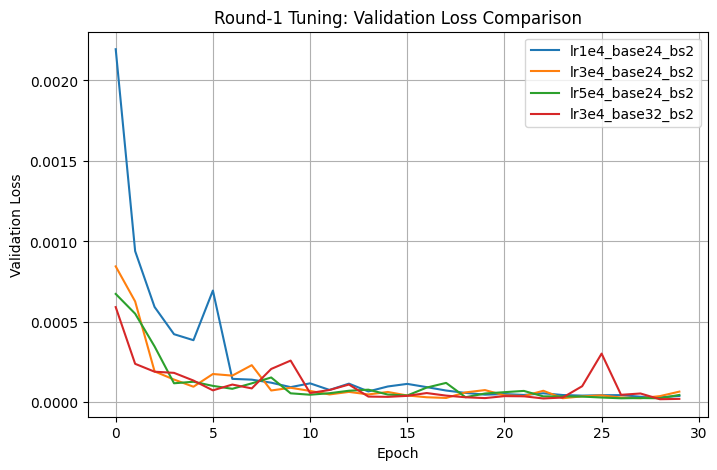

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_tuning_round1/round1_val_loss_comparison.png


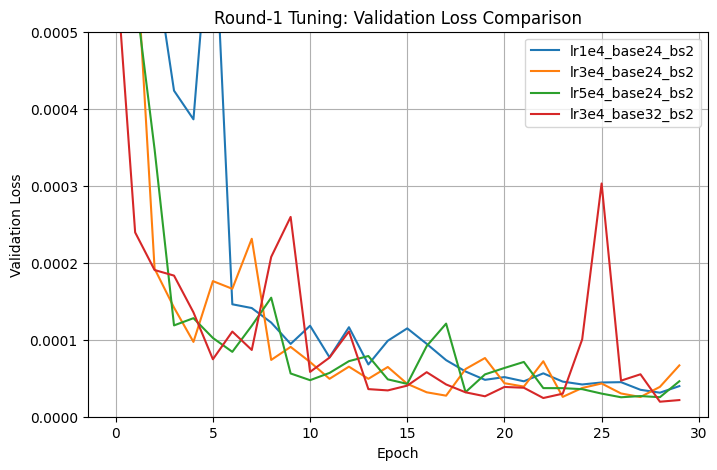

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_tuning_round1/round1_val_loss_comparison_scaled_0_to_5e-4.png


In [10]:
# Step 10: Plot and compare runs

def plot_val_loss_comparison(all_curves, save_path, scaled=False):
    fig, ax = plt.subplots(figsize=(8, 5))

    for run_name, curves in all_curves.items():
        ax.plot(curves["val_losses"], label=run_name)

    ax.set_title("Round-1 Tuning: Validation Loss Comparison")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss")
    if scaled:
        ax.set_ylim(0.0, 5e-4)
    ax.grid(True)
    ax.legend()

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

plot_val_loss_comparison(
    all_curves,
    OUT_DIR / "round1_val_loss_comparison.png",
    scaled=False
)

plot_val_loss_comparison(
    all_curves,
    OUT_DIR / "round1_val_loss_comparison_scaled_0_to_5e-4.png",
    scaled=True
)

### Step 11 — Select the best 1–2 runs

In [11]:
# Step 11: Select the best 1–2 runs

top2_df = results_df.head(2).copy()
top2_df

,run_name,lr,base_ch,batch_size,epochs,best_epoch,best_val_loss,final_train_loss,final_val_loss,final_val_mse,final_val_mae,elapsed_min,best_ckpt_path,latest_ckpt_path
0,lr3e4_base32_bs2,0.0003,32,2,30,29,0.000019,0.000049,0.000022,0.000025,0.003278,3.904007,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...
1,lr5e4_base24_bs2,0.0005,24,2,30,27,0.000025,0.000034,0.000046,0.000030,0.003526,3.760210,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...


### Step 12 — Continuation function for top runs

In [12]:
# Step 12: Continuation function

def continue_best_run(best_ckpt_path, target_epoch=50):
    best_ckpt_path = Path(best_ckpt_path)
    ckpt = torch.load(best_ckpt_path, map_location="cpu")
    config = ckpt["config"]

    run_name = config["run_name"] + f"_cont_to_{target_epoch}"
    lr = config["lr"]
    base_ch = config["base_ch"]
    batch_size = config["batch_size"]

    train_loader, val_loader = make_loaders(batch_size=batch_size)

    model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=base_ch).to(device)
    model.load_state_dict(ckpt["model_state_dict"])

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    train_losses = ckpt.get("train_losses", []).copy()
    val_losses = ckpt.get("val_losses", []).copy()

    start_epoch = ckpt["epoch"]
    best_val_loss = min(val_losses) if len(val_losses) > 0 else float("inf")
    best_epoch = int(np.argmin(val_losses)) + 1 if len(val_losses) > 0 else -1

    latest_ckpt_path = CKPT_DIR / f"{run_name}_latest.pt"
    cont_best_ckpt_path = CKPT_DIR / f"{run_name}_best.pt"

    start_time = time.time()

    for epoch in range(start_epoch + 1, target_epoch + 1):
        train_loss = train_one_epoch_flow(model, train_loader, optimizer, device, scaler)
        val_loss = evaluate_flow_matching_loss(model, val_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"[{run_name}] Epoch {epoch}/{target_epoch} | "
            f"train loss = {train_loss:.6f} | "
            f"val loss = {val_loss:.6f}"
        )

        save_checkpoint(
            latest_ckpt_path,
            model,
            optimizer,
            epoch,
            train_losses,
            val_losses,
            config
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            save_checkpoint(
                cont_best_ckpt_path,
                model,
                optimizer,
                epoch,
                train_losses,
                val_losses,
                config
            )

    # Final metrics
    final_best_ckpt = torch.load(cont_best_ckpt_path, map_location="cpu")
    model.load_state_dict(final_best_ckpt["model_state_dict"])
    model.eval()

    final_metrics = evaluate_flow_prediction_metrics(model, val_loader, device, n_steps=30)

    elapsed_min = (time.time() - start_time) / 60.0

    result = {
        "run_name": run_name,
        "original_lr": lr,
        "original_base_ch": base_ch,
        "batch_size": batch_size,
        "start_epoch": start_epoch,
        "target_epoch": target_epoch,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "final_val_mse": final_metrics["mse"],
        "final_val_mae": final_metrics["mae"],
        "elapsed_min": elapsed_min,
        "best_ckpt_path": str(cont_best_ckpt_path),
        "latest_ckpt_path": str(latest_ckpt_path),
    }

    return result, train_losses, val_losses

### Step 13 — Continue the best 1–2 runs

In [13]:
# Step 13: Continue the best 1–2 runs

continuation_results = []
continuation_curves = {}

for _, row in top2_df.iterrows():
    result, train_losses, val_losses = continue_best_run(
        best_ckpt_path=row["best_ckpt_path"],
        target_epoch=50
    )
    continuation_results.append(result)
    continuation_curves[result["run_name"]] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

cont_df = pd.DataFrame(continuation_results)
cont_df = cont_df.sort_values("best_val_loss", ascending=True).reset_index(drop=True)

cont_csv_path = OUT_DIR / "round1_continuation_results.csv"
cont_df.to_csv(cont_csv_path, index=False)

print("Saved:", cont_csv_path)
cont_df

/tmp/ipykernel_838/2208080590.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_838/1717672140.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_838/1717672140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[lr3e4_base32_bs2_cont_to_50] Epoch 30/50 | train loss = 0.000042 | val loss = 0.000033
[lr3e4_base32_bs2_cont_to_50] Epoch 31/50 | train loss = 0.000036 | val loss = 0.000023
[lr3e4_base32_bs2_cont_to_50] Epoch 32/50 | train loss = 0.000029 | val loss = 0.000017
[lr3e4_base32_bs2_cont_to_50] Epoch 33/50 | train loss = 0.000037 | val loss = 0.000016
[lr3e4_base32_bs2_cont_to_50] Epoch 34/50 | train loss = 0.000037 | val loss = 0.000024
[lr3e4_base32_bs2_cont_to_50] Epoch 35/50 | train loss = 0.000043 | val loss = 0.000033
[lr3e4_base32_bs2_cont_to_50] Epoch 36/50 | train loss = 0.000032 | val loss = 0.000033
[lr3e4_base32_bs2_cont_to_50] Epoch 37/50 | train loss = 0.000030 | val loss = 0.000037
[lr3e4_base32_bs2_cont_to_50] Epoch 38/50 | train loss = 0.000037 | val loss = 0.000021
[lr3e4_base32_bs2_cont_to_50] Epoch 39/50 | train loss = 0.000030 | val loss = 0.000046
[lr3e4_base32_bs2_cont_to_50] Epoch 40/50 | train loss = 0.000031 | val loss = 0.000029
[lr3e4_base32_bs2_cont_to_50] Ep

,run_name,original_lr,original_base_ch,batch_size,start_epoch,target_epoch,best_epoch,best_val_loss,final_train_loss,final_val_loss,final_val_mse,final_val_mae,elapsed_min,best_ckpt_path,latest_ckpt_path
0,lr5e4_base24_bs2_cont_to_50,0.0005,24,2,27,50,43,0.000015,0.000035,0.000019,0.000017,0.002662,2.919782,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...
1,lr3e4_base32_bs2_cont_to_50,0.0003,32,2,29,50,33,0.000016,0.000030,0.000054,0.000020,0.003022,2.726104,/content/drive/MyDrive/rectified_flow_ct2dose/...,/content/drive/MyDrive/rectified_flow_ct2dose/...


### Step 14 — Save a concise markdown summary

In [14]:
# Step 14: Save a concise markdown summary

summary_lines = []
summary_lines.append("# Round-1 Tuning Summary\n")
summary_lines.append("## Main settings")
summary_lines.append("- fixed split: 2000 train / 500 validation")
summary_lines.append("- fixed dataset and evaluation protocol")
summary_lines.append("- tuned learning rate and base channel size first\n")

summary_lines.append("## Round-1 screening results")
for _, row in results_df.iterrows():
    summary_lines.append(
        f"- {row['run_name']}: best_val_loss={row['best_val_loss']:.6e}, "
        f"final_val_mse={row['final_val_mse']:.6e}, final_val_mae={row['final_val_mae']:.6f}"
    )

summary_lines.append("\n## Continuation results")
for _, row in cont_df.iterrows():
    summary_lines.append(
        f"- {row['run_name']}: best_val_loss={row['best_val_loss']:.6e}, "
        f"final_val_mse={row['final_val_mse']:.6e}, final_val_mae={row['final_val_mae']:.6f}"
    )

summary_path = OUT_DIR / "round1_tuning_summary.md"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))

print("Saved:", summary_path)
print("\n".join(summary_lines))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/phase3_tuning_round1/round1_tuning_summary.md
# Round-1 Tuning Summary

## Main settings
- fixed split: 2000 train / 500 validation
- fixed dataset and evaluation protocol
- tuned learning rate and base channel size first

## Round-1 screening results
- lr3e4_base32_bs2: best_val_loss=1.949607e-05, final_val_mse=2.527059e-05, final_val_mae=0.003278
- lr5e4_base24_bs2: best_val_loss=2.528959e-05, final_val_mse=2.972125e-05, final_val_mae=0.003526
- lr3e4_base24_bs2: best_val_loss=2.559936e-05, final_val_mse=3.527792e-05, final_val_mae=0.003564
- lr1e4_base24_bs2: best_val_loss=3.121188e-05, final_val_mse=3.586984e-05, final_val_mae=0.004086

## Continuation results
- lr5e4_base24_bs2_cont_to_50: best_val_loss=1.489855e-05, final_val_mse=1.701601e-05, final_val_mae=0.002662
- lr3e4_base32_bs2_cont_to_50: best_val_loss=1.594063e-05, final_val_mse=1.978862e-05, final_val_mae=0.003022
